# Cohort Retention

In [2]:
# ====== 1. Upload File CSV ======
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving dataset (4).csv to dataset (4).csv


## 1. Library

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
# Ambil nama file yang di-upload
filename = list(uploaded.keys())[0]
print("File uploaded:", filename)

# ====== 2. Baca CSV ======
df = pd.read_csv(filename, sep=',')
df.head()

File uploaded: dataset (4).csv


,id,order_date,user_id
0,114363,2019-01-01,53424
1,114364,2019-01-01,77226
2,114366,2019-01-01,67632
3,114369,2019-01-01,63167
4,114370,2019-01-01,32047


## 2. Analisis Cohort Retention Berdasarkan Bulan Akuisisi Pelanggan
Metrik utama: Monthly Retention Rate

Menggunakan Monthly Retention Rate sebagai metrik utama untuk memantau proporsi pelanggan unik yang kembali melakukan pembelian setiap bulan, dengan fokus pada perilaku jangka menengah yang relevan untuk strategi engagement dan retensi.

Monthly retention dipilih karena transaksi makanan tidak terjadi setiap hari dan setiap minggu secara konsisten. Monthly retention lebih stabil, mewakili pola repeat order yang realistis, dan menghasilkan cohort yang bersih, mudah dibaca, serta relevan untuk keputusan bisnis.

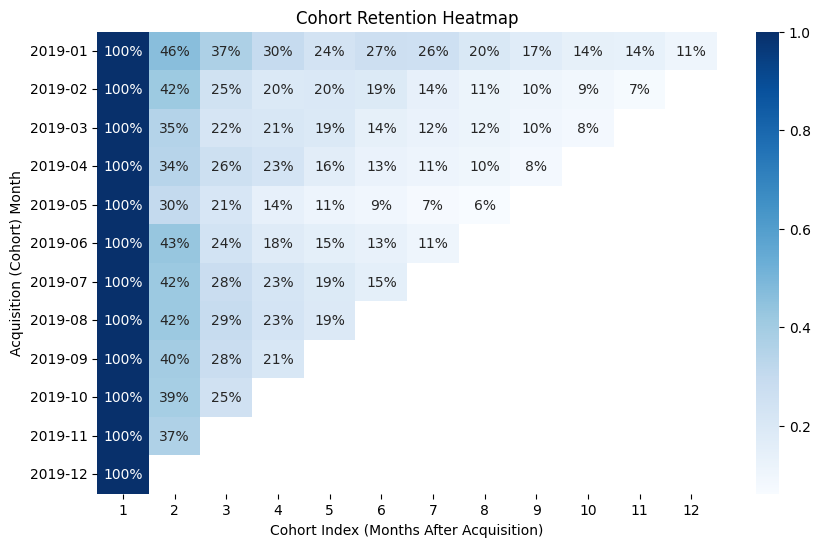

In [8]:
# Mengubah kolom order_date dari string menjadi tipe datetime
df['order_date'] = pd.to_datetime(df['order_date'])

#Buat kolom order_month dan cohort_month
df['order_month'] = df['order_date'].dt.to_period('M')
df['cohort_month'] = df.groupby('user_id')['order_date'].transform('min').dt.to_period('M')
##order_month: bulan transaksi saat itu → memudahkan analisis per bulan
##cohort_month: bulan pertama kali customer melakukan pembelian → menandai cohort akuisisi tiap user
##Dengan ini, kita bisa mengelompokkan pelanggan berdasarkan bulan mereka pertama kali muncul

#Hitung Cohort Index
df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 +
    (df['order_month'].dt.month - df['cohort_month'].dt.month) + 1
)
##cohort_index = bulan ke berapa pelanggan tersebut sejak akuisisi.
##Contoh:
##Cohort bulan Januari, customer membeli lagi di Februari → cohort_index = 2
##Cohort bulan Maret, customer membeli lagi di Maret → cohort_index = 1
##Ini digunakan untuk menghitung retention bulan ke-bulan.

#Hitung jumlah customer unik per cohort per bulan
cohort_data = df.groupby(['cohort_month','cohort_index'])['user_id'].nunique().reset_index()

# jumlah customer pertama (baseline cohort)
cohort_size = cohort_data[cohort_data['cohort_index']==1][['cohort_month','user_id']]
cohort_size = cohort_size.rename(columns={'user_id':'cohort_size'})
cohort_data = cohort_data.merge(cohort_size, on='cohort_month')

# hitung retention rate
cohort_data['retention_rate'] = cohort_data['user_id'] / cohort_data['cohort_size']

# pivot untuk heatmap
cohort_pivot = cohort_data.pivot(index='cohort_month',
                                 columns='cohort_index',
                                 values='retention_rate')

# plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cohort_pivot, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Heatmap")
plt.ylabel("Acquisition (Cohort) Month")
plt.xlabel("Cohort Index (Months After Acquisition)")
plt.show()

## 3. Detail Heatmap
Heatmap ini menunjukkan:

* baris = cohort, yaitu bulan pertama customer melakukan order

* kolom = bulan ke-berapa sejak customer pertama kali beli

* angka di dalam tabel = persentase customer yang masih melakukan pembelian di bulan tersebut

## 4. Analisis Heatmap

Retention Month+1 berada di 35–46%, artinya setengah customer hilang setelah bulan pertama.

Pada bulan ke-2 hingga ke-4 terlihat penurunan tajam, yang menandakan periode kritis terjadinya churn.

Sekitar 10–15% customer bertahan hingga bulan ke-6, membentuk kelompok pengguna loyal.

Distribusi order membentuk pola long-tail: mayoritas customer hanya order 1–2 kali, dan hanya sedikit customer yang membuat banyak transaksi.

## 5. Rekomendasi Bisnis

* Pengalaman pertama cust belum cukup untuk membuat cust melakukan repeat order
* Perlu lebih aktif mengingatkan dan menarik cust sebelum hilang. Bisa menggunakan promo, notifikasi, rekomendasi produk
* Cust loyal sekitar 10-15% bisa diberi promo loyalitas, diskon khusus, atau rekomendasi yang lebih personal.
* Setiap cohort menunjukkan pola yang mirip, artinya performa produk konsisten.
* Dorong lebih banyak cust melakukan repeat order.